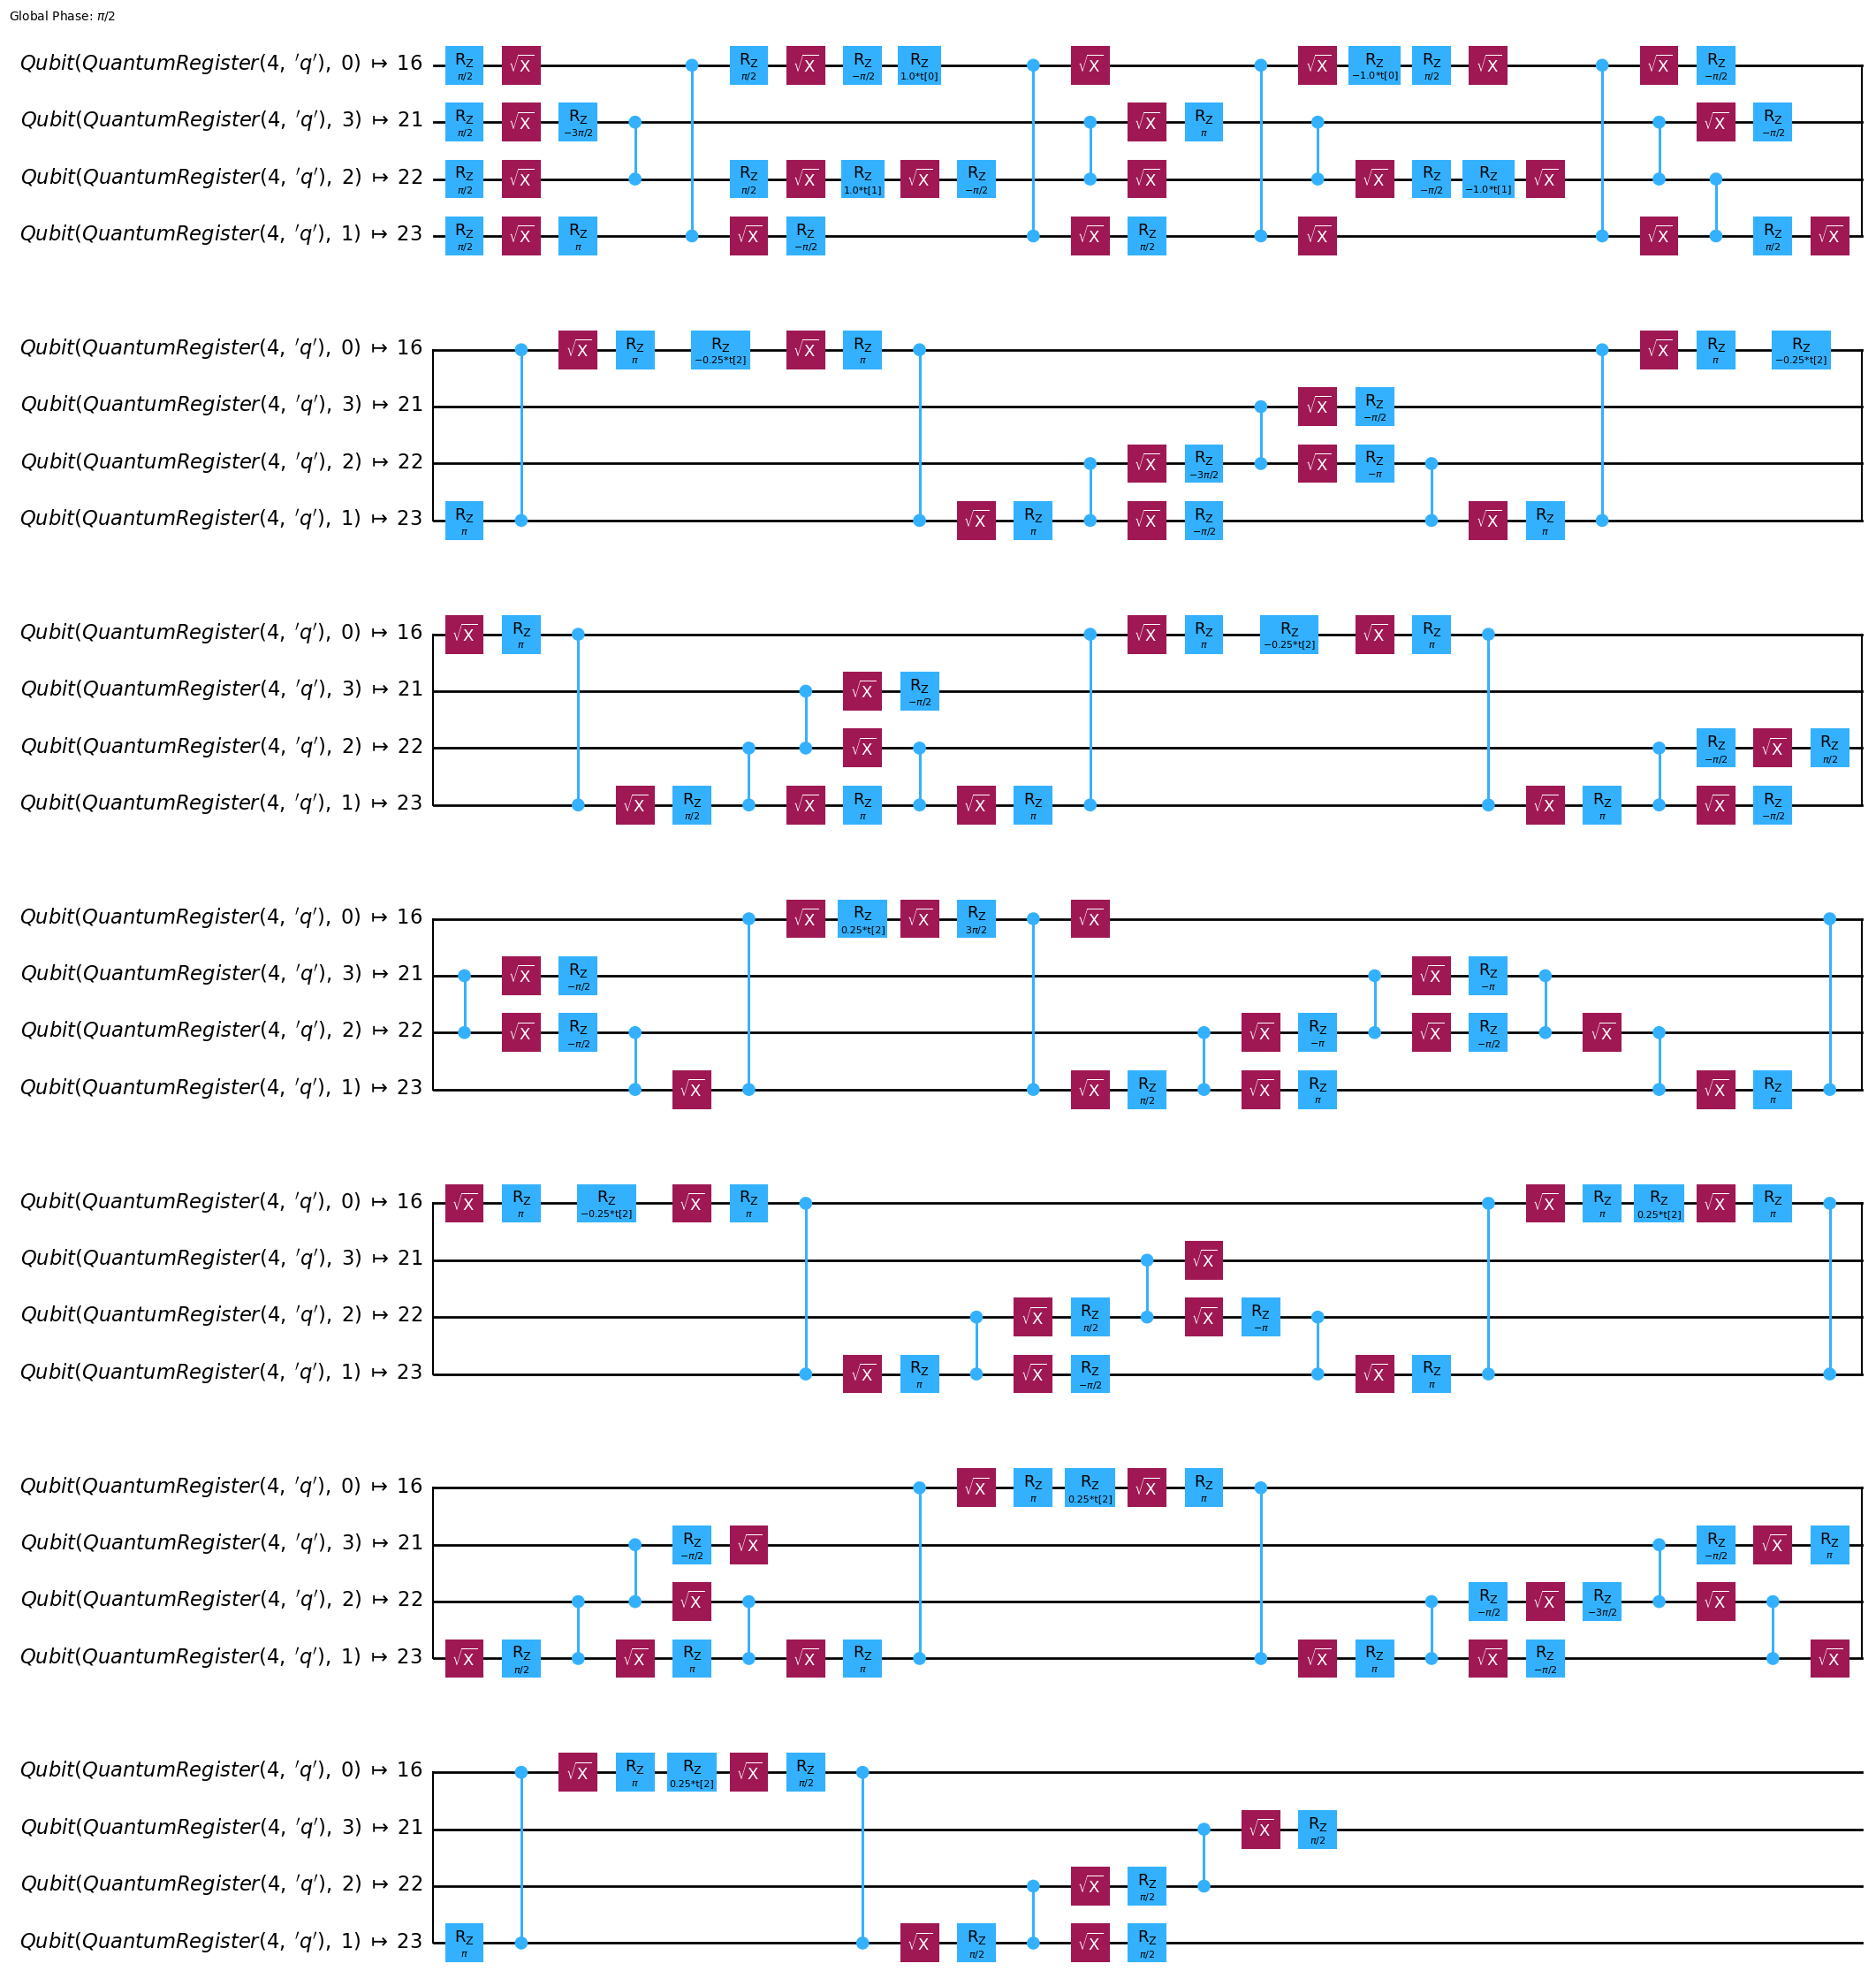

In [19]:
import qiskit.qpy as qpy
with open("Data_results/Bond_075/ansatz.qpy", "rb") as f:
    circuits = qpy.load(f)

ansatz = circuits[0]
ansatz.draw("mpl", idle_wires = False)

In [ ]:
import numpy as np
import pandas as pd

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit



from qiskit_nature.second_q.mappers import JordanWignerMapper
mapper = JordanWignerMapper()

from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

num_spatial_orbitals = 2
num_particles = (1, 1)
# ansatz = UCCSD(
#     num_spatial_orbitals,
#     num_particles,
#     mapper,
#     initial_state=HartreeFock(
#         num_spatial_orbitals,
#         num_particles,
#         mapper,
#     ),
# )


In [ ]:

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA

from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from scipy.optimize import minimize

# from qiskit.transpiler import PassManager
# from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
# target = backend.target
# pm = generate_preset_pass_manager(target=target, optimization_level=3)
# ansatz_isa = pm.run(ansatz)

from time import time


In [20]:


energies = []
ground_energies = []
optimizer_times = []
iteration_number = []
optimizer_results = []
nuclear_repulsion_energies = []
energy_histories = []
optimal_parameters_list = []


# Bond lengths in Angstrom
bond_lengths = np.arange(0.30, 1.50, 0.05) 


for r in bond_lengths:
    # Define H2 geometry
    geometry = f"H 0 0 0; H 0 0 {r}"

    # PySCF driver
    driver = PySCFDriver(
        atom=geometry,
        basis="sto3g",
        spin=0,
        charge=0,
        unit=DistanceUnit.ANGSTROM,
    )

    # Run electronic structure calculation
    problem = driver.run()
    nuclear_repulsion = problem.hamiltonian.nuclear_repulsion_energy


    #print(f"Running VQE for bond length {r} Å with initial parameters: {initial_parameters[r]}")
    vqe_solver = VQE(estimator, ansatz, COBYLA())
    vqe_solver.initial_point = [0.0] * ansatz.num_parameters      # IMPORTANT
    x0 = vqe_solver.initial_point

    solver = GroundStateEigensolver(mapper, vqe_solver)

    main_operator, aux_ops = solver.get_qubit_operators(problem)

    H = main_operator
    hamiltonian_isa = H.apply_layout(ansatz.layout)

    energy_history = []

    def cost_func(params, ansatz, H, estimator):
        pub = (ansatz, [H], [params])
        result = estimator.run(pubs=[pub]).result()
        energy = result[0].data.evs[0]
        energy_history.append(energy)  
        return energy

    start_time = time()
    result = minimize(
        cost_func,
        x0,
        args=(ansatz, hamiltonian_isa, estimator),
        method="cobyla",
        options={"maxiter": 50, "disp": True},)

    optimizer_time = time() - start_time
    energy = result.fun
    optimal_parameters = result.x
    ground_state_energy = energy + nuclear_repulsion
    print(f"Ground state energy for bond length {r} Å: {ground_state_energy:.6f} Hartree")


    energies.append(energy)
    ground_energies.append(ground_state_energy)
    optimizer_results.append(result)
    optimizer_times.append(optimizer_time)
    nuclear_repulsion_energies.append(nuclear_repulsion)
    iteration_number.append(result.nfev)
    energy_histories.append(energy_history)
    optimal_parameters_list.append(optimal_parameters)





ValueError: Maximum allowed dimension exceeded

In [6]:

# Create table
df = pd.DataFrame({
    "Bond Length": bond_lengths,
    "Results": optimizer_results,
    "Ground State Energy (Hartree)": ground_energies,
    "Time (s)": optimizer_times,
    "Nuclear Repulsion Energy (Hartree)": nuclear_repulsion_energies,
    "Electronic Energies (Hartree)": energies,
    "Convergence History": energy_histories,
    "optimal_parameters_list": optimal_parameters_list
})
print(df)

    Bond Length                                            Results  \
0          0.30  {'x': [-0.00010924253724178914, 7.165296948462...   
1          0.35  {'x': [0.00019901825558227797, 4.7173504140709...   
2          0.40  {'x': [5.510899291746139e-05, -5.3734717478272...   
3          0.45  {'x': [0.00043782361712711975, -0.000377190151...   
4          0.50  {'x': [4.5424555673077576e-05, -4.405373162146...   
5          0.55  {'x': [1.2596427348060679e-05, 2.4806771598594...   
6          0.60  {'x': [0.00014094776911023588, -0.000220959107...   
7          0.65  {'x': [-2.7503074428459067e-06, -2.21056338497...   
8          0.70  {'x': [2.7811250804285104e-06, 4.6304423159623...   
9          0.75  {'x': [0.00012416382729613142, -0.000219442344...   
10         0.80  {'x': [-3.522679867962373e-05, -9.991950598476...   
11         0.85  {'x': [0.00036969316551557026, -0.000354942535...   
12         0.90  {'x': [5.5005620540980125e-05, 4.0937608373318...   
13         0.95  {'x

In [8]:
# df.to_pickle("dataframe.pkl")
# df = pd.read_pickle("dataframe.pkl")

import pickle
location = "Data_results/Transpilation_error_results.pkl"
df.to_pickle(location)

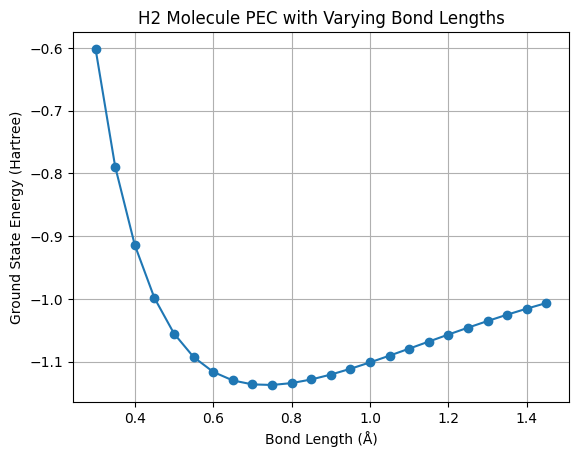

In [7]:
from matplotlib import pyplot as plt

plt.plot(bond_lengths, ground_energies, marker='o')
plt.grid(True)
plt.xlabel("Bond Length (Å)")
plt.ylabel("Ground State Energy (Hartree)")
plt.title("H2 Molecule PEC with Varying Bond Lengths")
plt.show()

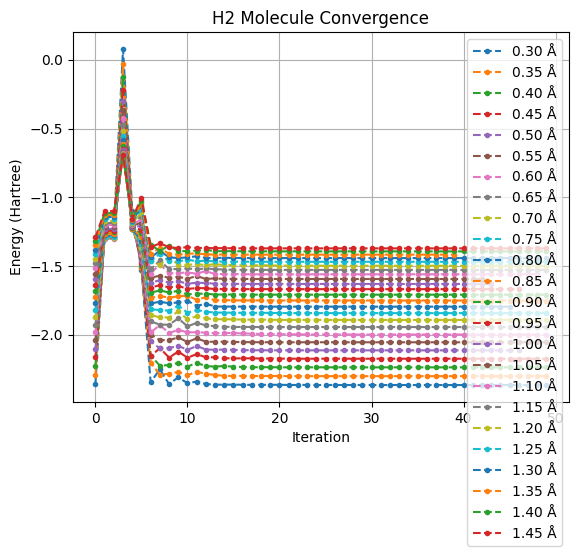

In [9]:
for history in energy_histories:
    plt.plot(history, marker='.', linestyle='--')
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")
plt.title("H2 Molecule Convergence")
plt.legend([f"{r:.2f} Å" for r in bond_lengths])
plt.show()

ansatz depth = 4


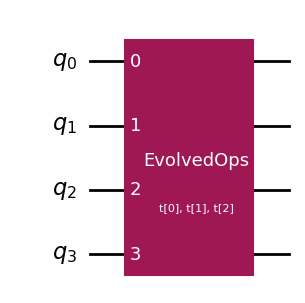

In [10]:
print(f"ansatz depth = {ansatz.decompose().depth()}")
ansatz.draw(output="mpl", idle_wires=False, style="iqp")

In [11]:
df.head(7)

,Bond Length (Å),Results,Ground State Energy (Hartree),Time (s),Nuclear Repulsion Energy (Hartree),Electronic Energies (Hartree),Convergence History,optimal_parameters_list
0,0.30,"{'x': [0.0821556, 0.03705277, -0.11171107], 's...",-0.413121,81.597544,1.763924,-2.177045,"[-2.1770454068621152, -1.0220554416210827, -1....","[0.0821556, 0.03705277, -0.11171107]"
1,0.45,"{'x': [-0.0033706870346540824, 0.0451681604390...",-0.839389,75.487845,1.175949,-2.015338,"[-2.0105942736722593, -1.1325272760607852, -1....","[-0.0033706870346540824, 0.045168160439022886,..."
2,0.60,"{'x': [0.11575914633884257, 2.8431066627275514...",-0.988101,71.791566,0.881962,-1.870063,"[-1.8607195786772115, -1.1598688180357695, -1....","[0.11575914633884257, 2.8431066627275514e-05, ..."
3,0.75,"{'x': [0.0821556, 0.03705277, -0.11171107], 's...",-1.029875,69.016259,0.705570,-1.735445,"[-1.7354449074399125, -1.1717193782154336, -1....","[0.0821556, 0.03705277, -0.11171107]"
4,0.90,"{'x': [0.0821556, 0.03705277, -0.11171107], 's...",-1.033038,73.185739,0.587975,-1.621012,"[-1.621012277530207, -1.161758090250079, -1.19...","[0.0821556, 0.03705277, -0.11171107]"
5,1.05,"{'x': [0.06107828723891725, -0.077151600565461...",-1.014423,68.484784,0.503978,-1.518401,"[-1.5106281806885804, -1.1313164249842411, -1....","[0.06107828723891725, -0.07715160056546114, -0..."
6,1.20,"{'x': [0.01809516726729382, 0.0142697567008296...",-0.990799,66.938597,0.440981,-1.431780,"[-1.4183306359694197, -1.1066713250367302, -1....","[0.01809516726729382, 0.014269756700829622, -0..."


In [13]:
df_combined = pd.read_pickle("Data_results/Combined_Results.pkl")
df_combined.head()

,Bond Length,Results_QPU,Ground State Energy (Hartree)_QPU,Time (s)_QPU,Nuclear Repulsion Energy (Hartree)_QPU,Electronic Energies (Hartree)_QPU,Convergence History_QPU,optimal_parameters_list_QPU,Results_Aer,Ground State Energy (Hartree)_Aer,...,Electronic Energies (Hartree)_Aer,Convergence History_Aer,optimal_parameters_list_Aer,Results,Ground State Energy (Hartree),Time (s),Nuclear Repulsion Energy (Hartree),Electronic Energies (Hartree),Convergence History,optimal_parameters_list
0,0.45,"{'x': [-0.0033706870346540824, 0.0451681604390...",-0.729711,976.281680,1.175949,-1.905661,"[-1.9056607601812363, -1.1087295761364029, -1....","[-0.0033706870346540824, 0.045168160439022886,...","{'x': [0.09002597984269597, 0.0439822450891662...",-0.789255,...,-1.965205,"[-1.9618686009992872, -1.0882514290141028, -1....","[0.09002597984269597, 0.043982245089166275, -0...","{'x': [-0.01594725525986933, 0.006576564931376...",-0.997445,0.220123,1.175949,-2.173395,"[-2.158462301041319, -1.1928303594183982, -1.2...","[-0.01594725525986933, 0.0065765649313765774, ..."
1,0.60,"{'x': [0.15019989790151939, -0.036218425787422...",-0.858650,286.460181,0.881962,-1.740612,"[-1.6922736976601185, -1.0871196283339861, -1....","[0.15019989790151939, -0.0362184257874225, -0....","{'x': [0.025222257972730026, 0.004318705928873...",-0.946851,...,-1.828813,"[-1.8194324409574376, -1.1517580933783174, -1....","[0.025222257972730026, 0.004318705928873269, -...","{'x': [-0.005676903382171844, -0.0091916187861...",-1.116049,0.186570,0.881962,-1.998011,"[-1.9883462678695967, -1.2294621437209592, -1....","[-0.005676903382171844, -0.009191618786169416,..."
2,0.75,"{'x': [0.05622898238231749, 0.0619351373444218...",-0.908009,1897.637656,0.705570,-1.613579,0,0,"{'x': [0.06094690279475859, -0.058352602161209...",-1.004726,...,-1.710296,"[-1.7003469855677, -1.1642390732025416, -1.221...","[0.06094690279475859, -0.058352602161209854, -...","{'x': [0.0044290821008509465, 0.00997089209238...",-1.135370,0.178057,0.705570,-1.840939,"[-1.8352483392679613, -1.2307562334968907, -1....","[0.0044290821008509465, 0.009970892092380855, ..."
3,0.90,"{'x': [0.10049179736462063, 0.0528177715341626...",-0.954234,726.472458,0.587975,-1.542208,"[-1.538616650592773, -1.112869681623636, -1.17...","[0.10049179736462063, 0.05281777153416269, -0....","{'x': [-0.015712921218211776, 0.05923414662417...",-1.013212,...,-1.601187,"[-1.583719970251413, -1.1455486002218604, -1.1...","[-0.015712921218211776, 0.05923414662417866, -...","{'x': [-0.002182320428635136, -0.0091024659921...",-1.120386,0.194908,0.587975,-1.708361,"[-1.7001868714609452, -1.2100592517336004, -1....","[-0.002182320428635136, -0.009102465992133936,..."
4,1.05,"{'x': [-0.05268460867377192, -0.00965118800572...",-0.963867,1389.771611,0.503978,-1.467846,"[-1.4404440826618614, -1.1348218217114512, -1....","[-0.05268460867377192, -0.009651188005724873, ...","{'x': [0.041279564745483964, -0.06453210947936...",-0.998906,...,-1.502884,"[-1.4852667273697044, -1.122189703966129, -1.1...","[0.041279564745483964, -0.06453210947936355, -...","{'x': [0.013579411534498787, -0.00132077074226...",-1.089969,0.168210,0.503978,-1.593948,"[-1.5816989599760347, -1.1785428718088649, -1....","[0.013579411534498787, -0.0013207707422697324,..."


In [17]:
df_Svec = pd.read_pickle("Data_results/Statevector_Results/Statevector_Results.pkl")
df_Svec.head()

,Bond Length,Results,Ground State Energy (Hartree),Time (s),Nuclear Repulsion Energy (Hartree),Electronic Energies (Hartree),Convergence History,optimal_parameters_list
0,0.30,"{'x': [-0.019763072203464422, 0.00658970185559...",-0.600759,0.267545,1.763924,-2.364683,"[-2.340573527555158, -1.1155722069641365, -1.1...","[-0.019763072203464422, 0.0065897018555995945,..."
1,0.35,"{'x': [0.002005024661644707, 0.005846551962562...",-0.789182,0.228899,1.511935,-2.301117,"[-2.279420902628475, -1.1453831826424905, -1.1...","[0.002005024661644707, 0.0058465519625622965, ..."
2,0.40,"{'x': [-0.02059801123137401, 0.005641471995903...",-0.913357,0.166206,1.322943,-2.236300,"[-2.2184181081598573, -1.1713488089183308, -1....","[-0.02059801123137401, 0.005641471995903158, -..."
3,0.45,"{'x': [-0.01594725525986933, 0.006576564931376...",-0.997445,0.220123,1.175949,-2.173395,"[-2.158462301041319, -1.1928303594183982, -1.2...","[-0.01594725525986933, 0.0065765649313765774, ..."
4,0.50,"{'x': [-0.016419325527923436, 0.00578139633301...",-1.054337,0.190982,1.058354,-2.112692,"[-2.100007320448122, -1.2096042793649495, -1.2...","[-0.016419325527923436, 0.0057813963330108145,..."


In [15]:
df_Aer = pd.read_pickle("Data_results/Aer_Simulator_Results/Aer_Results_2.pkl")
df_Aer.head()

,Bond Length,Results,Ground State Energy (Hartree),Time (s),Nuclear Repulsion Energy (Hartree),Electronic Energies (Hartree),Convergence History,optimal_parameters_list
0,0.30,"{'x': [0.0821556, 0.03705277, -0.11171107], 's...",-0.353718,56.362597,1.763924,-2.117642,"[-2.1176416714917745, -0.9866259857885347, -1....","[0.0821556, 0.03705277, -0.11171107]"
1,0.35,"{'x': [0.11585993682825538, 0.0001201600330953...",-0.535602,64.197770,1.511935,-2.047537,"[-2.0430657683836935, -1.046447353722713, -1.1...","[0.11585993682825538, 0.00012016003309530537, ..."
2,0.40,"{'x': [0.0821556, 0.03705277, -0.11171107], 's...",-0.696956,52.752779,1.322943,-2.019899,"[-2.0198985409964285, -1.0690779382432836, -1....","[0.0821556, 0.03705277, -0.11171107]"
3,0.45,"{'x': [0.09002597984269597, 0.0439822450891662...",-0.789255,49.257748,1.175949,-1.965205,"[-1.9618686009992872, -1.0882514290141028, -1....","[0.09002597984269597, 0.043982245089166275, -0..."
4,0.50,"{'x': [0.11549750570116155, -0.000207360491114...",-0.865947,60.330608,1.058354,-1.924301,"[-1.9036647195945564, -1.1193171797432135, -1....","[0.11549750570116155, -0.00020736049111409055,..."


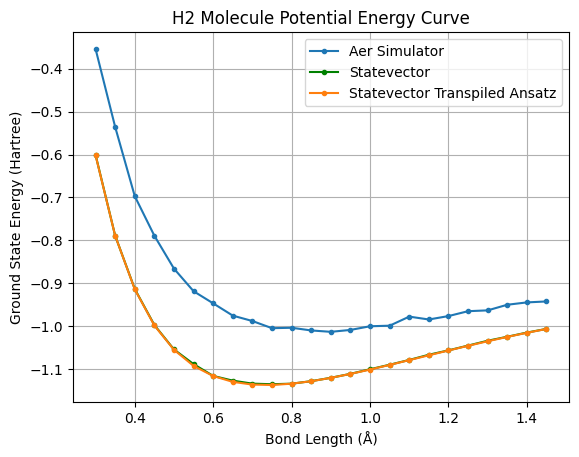

In [18]:
plt.plot(df_Aer["Bond Length"], df_Aer["Ground State Energy (Hartree)"], marker='.', label='Aer Simulator')
# plt.plot(df_QPU["Bond Length"], df_QPU["Ground State Energy (Hartree)"], marker='.', color='red', label='QPU')
plt.plot(df_Svec["Bond Length"], df_Svec["Ground State Energy (Hartree)"], marker='.', color='green', label='Statevector')
plt.plot(df["Bond Length"], df["Ground State Energy (Hartree)"], marker='.', label='Statevector Transpiled Ansatz')
plt.xlabel("Bond Length (Å)")
plt.ylabel("Ground State Energy (Hartree)") 
plt.grid(True)
plt.title("H2 Molecule Potential Energy Curve")
plt.legend()
plt.show()